In [118]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
load_dotenv()
import os

api_key = os.getenv("GOOGLE_API_KEY")

if os.environ['GOOGLE_API_KEY']:
    print("Google api key is set")
else:
    raise ValueError("Gemini API key is not set")


llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite", google_api_key=api_key, temperature=0.7)

Google api key is set


In [ ]:
from langchain_core.tools import tool
from gmail_service import get_gmail_service
from pathlib import Path
#get_email_thread(thread_id)
import base64
from RagPipeline import RagRetriever

retriever = RagRetriever()

@tool
def get_new_emails(max_results=10, search_query: str = ""):
    """
    Use this tool to access email and fetch new emails.

    Args:
        search_query: the specific topic or Gmail search query
                      for which the user wants to search email.
    """

    service = get_gmail_service()

    results = service.users().messages().list(
        userId="me",
        maxResults=max_results,
        q=search_query
    ).execute()

    messages = results.get("messages", [])

    emails = []

    def extract_body(payload):
        # Direct body
        body_data = payload.get("body", {}).get("data")

        if body_data:
            return base64.urlsafe_b64decode(
                body_data
            ).decode("utf-8", errors="ignore")

        # Multipart email
        for part in payload.get("parts", []):

            mime_type = part.get("mimeType", "")

            # Prefer plain text
            if mime_type == "text/plain":
                body_data = part.get("body", {}).get("data")

                if body_data:
                    return base64.urlsafe_b64decode(
                        body_data
                    ).decode("utf-8", errors="ignore")

            # Nested multipart
            if part.get("parts"):
                body = extract_body(part)

                if body:
                    return body

        return ""

    for message in messages:

        email = service.users().messages().get(
            userId="me",
            id=message["id"],
            format="full"
        ).execute()

        payload = email["payload"]

        headers = payload.get("headers", [])

        subject = ""
        sender = ""
        date = ""

        for header in headers:

            if header["name"].lower() == "subject":
                subject = header["value"]

            elif header["name"].lower() == "from":
                sender = header["value"]

            elif header["name"].lower() == "date":
                date = header["value"]

        body = extract_body(payload)

        emails.append({
            "id": message["id"],
            "sender": sender,
            "subject": subject,
            "date": date,
            "body": body
        })

    return emails

@tool
def search_internal_docs(query):
    """
    Use this tool to access internal documents required for email related issue or reply

    Args:
        query: To elaborate what type of document needed to be fetched
    """
    BASE_DIR = Path.cwd()
    file_path = BASE_DIR / 'docs'
    if retriever.data_exists() < 1:
        retriever.file_loader(file_path)
        retriever.text_splitting()

    result = retriever.document_retriever(query)
    return result


@tool
def search_memory(query):
    """
    Use this tool to load previous conversation to handle to validate user requests

    Args:
        query: To elaborate what type of data to be loaded from memory for further process  
    """
@tool
def draft_email(additional_info, body):
    """
    Use this tool to load previous conversation to handle to validate user requests

    Args:
        additional_info: info from user or from docs that needs to be added in email
        body: content of email to be sent  
    """
@tool
def send_email(to, subject, body):
    """
    Use this tool to reply to customer or clients by generating a proper professional email

    Args:
        to: Holds email of user to whom email is to be send
        subject: Subject of the email
        body: content of the email
    """

In [120]:
tools = [get_new_emails, search_internal_docs, search_memory, send_email]

llm_with_tools = llm.bind_tools(tools)

In [121]:
from typing import TypedDict, Annotated, List, Optional
from langgraph.graph.message import BaseMessage, add_messages
from pydantic import BaseModel, Field

class email_automation_schema(BaseModel):
    filtered_result: Optional[list] = Field(description="stores only those mails that needs to be observed or require response/reply")
    answer: str

class graph_schema(TypedDict):
    query: Annotated[List[BaseMessage], add_messages]
    tool_response: list
    filtered_result: list = Field(description="stores only those mails that needs to be observed or require response/reply")
    answer: str

In [122]:
llm_with_schema = llm.with_structured_output(email_automation_schema)

In [ ]:
from langchain_core.messages import ToolMessage, AIMessage, HumanMessage
from langchain_core.prompts import ChatPromptTemplate
def llm_node(state: graph_schema) -> graph_schema:
    query = state['query']
    print(f"Your query{query}")
    response = llm_with_tools.invoke(query)

    print(response)
    return {
        "query": [response]
    }

def tool_node(state: graph_schema) -> graph_schema:

    query = state['query'][-1]
    print(f"Tool node:{query}")
    tool_name = {tool.name: tool for tool in tools}

    tool_result = []

    for tool_call in query.tool_calls:
        tool = tool_name[tool_call["name"]]

        observation = tool.invoke(tool_call['args'])

        if tool_call["name"] == "get_new_emails":
            response = llm_with_schema.invoke(str(observation))
            tool_result.append(
                ToolMessage(
                    content=str(response.filtered_result),
                    tool_call_id=tool_call["id"]
                )
            )

        else:
            tool_result.append(ToolMessage(content=str(observation), tool_call_id=tool_call['id']))

    return {
        'query': tool_result
    }

def tool_decision(state: graph_schema) -> str:
    if state['query'][-1].tool_calls:
        return "tool_node"
    else:
        return "end"

def evaluator_node(state: graph_schema) -> graph_schema:
    tool_response = state['tool_response']

    prompt = ChatPromptTemplate.from_messages([
        ('system', """You are professional mail generator that help user draft a mail if they ask you to
        
        - Check for only those mails that is required to be observed needs a reply
        - If email needs reply tell how many mails require reply
        - else just summarize the mails as it is.
        """),
        ('user', """
            raw_result: {tool_response}
""")
    ])

    chain = prompt | llm_with_schema
    response = chain.invoke({"tool_response": tool_response})

    print(f"Response after evaluator funtion: {response}")
    return {
        "answer": response.answer,
        "filtered_result": response.filtered_result
    }

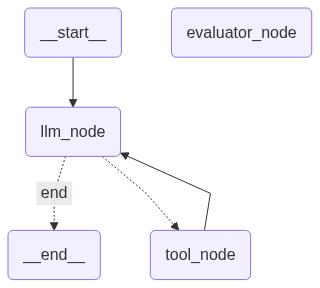

In [ ]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("llm_node", llm_node)
graph.add_node("tool_node", tool_node)
graph.add_node("evaluator_node", evaluator_node)

graph.add_edge(START, "llm_node")
graph.add_conditional_edges("llm_node", tool_decision, {"tool_node": "tool_node", "end": END})
graph.add_edge("tool_node", "llm_node")
graph.add_edge("llm_node", END)

email_agent = graph.compile()
email_agent

In [125]:
conversation = []

while True:
    query = input("Enter a query to proceed (stop to end task...)")

    if query == "stop":
        break

    conversation.append(HumanMessage(content=query))

    response = email_agent.invoke({
        "query": conversation,
        "answer": "",
        "filtered_result": []
    })

    print(response['query'][-1].content[0]['text'])
    
    conversation.append(AIMessage(content=response['query'][-1].content[0]['text']))

Your query[HumanMessage(content='access my email and check for mails that require reply', additional_kwargs={}, response_metadata={}, id='ee113948-ae7e-4468-a954-4951014e2673')]
content=[] additional_kwargs={'function_call': {'name': 'get_new_emails', 'arguments': '{"search_query": "is:unread"}'}, '__gemini_function_call_thought_signatures__': {'call_827504': 'EnEKbwERTTIPbrJZZ92dKEsqa/2OK/bB7sLDYZIR3XxAxV9SkKHWPKNwpybgeTXKGro0mOj0I8NRvwm6uSJ/cVP8a808AhkYRAbYsYId4jQUgRNO6kl8FhjOsYemZ0ZMedBbbXI0r/1orNPlc7p4iORtww=='}} response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'} id='lc_run--01a07090-9eaa-7a51-a58c-46e90caa8a56-0' tool_calls=[{'name': 'get_new_emails', 'args': {'search_query': 'is:unread'}, 'id': 'call_827504', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 345, 'output_tokens': 22, 'total_tokens': 367, 'input_token_details': {'cache_read': 0}}
Tool node:content=[] a